# GitHub Machine Learning Repository Analysis

## Data Science Level 3 - Term 2 Project

This project analyzes Machine Learning repositories collected from the GitHub API.

The project covers the complete data analytics workflow:

- Data collection from the GitHub API
- Data preparation and cleaning using Pandas
- Data storage using SQLite
- Data analysis using SQL
- Data visualization using Matplotlib
- Result interpretation
- Git and GitHub version control
- Responsible use of public data

## Project Objectives

The main objectives of this project are to:

1. Collect Machine Learning repository data from the GitHub API.
2. Convert the API response into a Pandas DataFrame.
3. Explore and clean the dataset.
4. Save the cleaned dataset as a CSV file.
5. Store the dataset in a SQLite database.
6. Analyze the repositories using SQL.
7. Create visualizations using Python and Matplotlib.
8. Interpret the main findings.
9. Manage and publish the project using Git and GitHub.
10. Reflect on the responsible use of public API data.

# Task 1: Data Collection & Preparation

In this task, repository data will be collected from the GitHub API.

The JSON response will be converted into a Pandas DataFrame, cleaned, prepared, and saved as `github_projects.csv`.

In [88]:
!pip install pandas requests matplotlib

In [89]:
# Step 1: Importing Libraries
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [90]:
# Step 2 - Retrieve Data from the GitHub API
url='https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100'
response=requests.get(url)
data=response.json()
print(response.status_code)

200


In [91]:
# Step 3: Convert the JSON Response into a Pandas DataFrame
data = response.json()
print(data.keys())

dict_keys(['total_count', 'incomplete_results', 'items'])


In [92]:
df = pd.DataFrame(data["items"])

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76059,3013,197047,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34269,2369,164226,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21970,12,89494,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15264,52,82527,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15612,26,74065,master,1.0


In [93]:
# step 4 explore dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [94]:
df.shape

(100, 82)

In [95]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [96]:
df.describe()

,id,size,stargazers_count,watchers_count,forks_count,open_issues_count,forks,open_issues,watchers,score
count,1.000000e+02,1.000000e+02,100.00000,100.00000,100.000000,100.000000,100.000000,100.000000,100.00000,100.0
mean,1.596683e+08,2.306494e+05,20805.20000,20805.20000,4811.610000,266.670000,4811.610000,266.670000,20805.20000,1.0
std,1.558514e+08,5.385851e+05,27277.96236,27277.96236,8763.262089,593.123662,8763.262089,593.123662,27277.96236,0.0
min,2.659950e+05,7.000000e+00,7485.00000,7485.00000,493.000000,0.000000,493.000000,0.000000,7485.00000,1.0
25%,6.347759e+07,6.914750e+03,9345.50000,9345.50000,1778.500000,12.000000,1778.500000,12.000000,9345.50000,1.0
50%,1.131206e+08,3.163150e+04,13467.00000,13467.00000,2875.500000,33.000000,2875.500000,33.000000,13467.00000,1.0
75%,1.957467e+08,1.603765e+05,20222.50000,20222.50000,4435.000000,183.500000,4435.000000,183.500000,20222.50000,1.0
max,8.025451e+08,3.028249e+06,197047.00000,197047.00000,76059.000000,3013.000000,76059.000000,3013.000000,197047.00000,1.0


In [97]:
## Step 5: Select the Required Columns
columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[columns]
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197047,76059,197047,3013,2015-11-07T01:19:20Z,2026-08-18T23:26:41Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164226,34269,164226,2369,2018-10-29T13:56:00Z,2026-08-18T23:20:15Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89494,21970,89494,12,2021-03-03T01:34:05Z,2026-08-19T00:14:23Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82527,15264,82527,52,2018-08-21T11:20:39Z,2026-08-19T00:34:50Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74065,15612,74065,26,2014-07-15T19:11:19Z,2026-08-19T00:12:22Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


## Step 6: Extract Required Values from Nested Columns

The `owner` and `license` columns contain nested information.

Only the required values will be extracted:

- `owner` → repository owner's login name
- `license` → license name

In [98]:
df["owner"].head()

,owner
0,"{'login': 'tensorflow', 'id': 15658638, 'node_..."
1,"{'login': 'huggingface', 'id': 25720743, 'node..."
2,"{'login': 'microsoft', 'id': 6154722, 'node_id..."
3,"{'login': 'fighting41love', 'id': 11475294, 'n..."
4,"{'login': 'josephmisiti', 'id': 246302, 'node_..."


In [99]:
df["owner"] = df["owner"].apply(
    lambda x: x.get("login") if isinstance(x, dict) else None
)

In [100]:
df["license"] = df["license"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)

In [101]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197047,76059,197047,3013,2015-11-07T01:19:20Z,2026-08-18T23:26:41Z,Apache License 2.0
1,transformers,huggingface,Python,164226,34269,164226,2369,2018-10-29T13:56:00Z,2026-08-18T23:20:15Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89494,21970,89494,12,2021-03-03T01:34:05Z,2026-08-19T00:14:23Z,MIT License
3,funNLP,fighting41love,Python,82527,15264,82527,52,2018-08-21T11:20:39Z,2026-08-19T00:34:50Z,None
4,awesome-machine-learning,josephmisiti,Python,74065,15612,74065,26,2014-07-15T19:11:19Z,2026-08-19T00:12:22Z,Other


Handle Missing Values

Missing values will be identified first.

Repositories without a specified programming language will be labeled as `Unknown`.

Repositories without a license will be labeled as `No License`.

In [102]:
## Step 7: Handle Missing Values
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [103]:
df["language"] = df["language"].fillna("Unknown")

In [104]:
df["license"] = df["license"].fillna("No License")

Handle Duplicate Records

Duplicate records can affect analysis and produce inaccurate results.

The dataset will be checked for duplicates and duplicate records will be removed.

In [105]:
## Step 8: Handle Duplicate Records
df.duplicated().sum()

np.int64(0)

In [106]:
df = df.drop_duplicates()

In [107]:
df.duplicated().sum()

np.int64(0)

Prepare the Dataset

The date columns will be converted to a suitable date format.

The column names will also be renamed to make them shorter and easier to use in SQL queries.

In [108]:
## Step 9: Prepare the Dataset
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [109]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

## Step 10: Save the Cleaned Dataset

The prepared dataset will be saved as:

`github_projects.csv`

This CSV file will be used in the next stage of the project.

In [110]:
df.to_csv("github_projects.csv", index=False)

In [111]:
## Step 11: Verify the Saved CSV File
df_check = pd.read_csv("github_projects.csv")

df_check.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197047,76059,197047,3013,2015-11-07 01:19:20+00:00,2026-08-18 23:26:41+00:00,Apache License 2.0
1,transformers,huggingface,Python,164226,34269,164226,2369,2018-10-29 13:56:00+00:00,2026-08-18 23:20:15+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89494,21970,89494,12,2021-03-03 01:34:05+00:00,2026-08-19 00:14:23+00:00,MIT License
3,funNLP,fighting41love,Python,82527,15264,82527,52,2018-08-21 11:20:39+00:00,2026-08-19 00:34:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74065,15612,74065,26,2014-07-15 19:11:19+00:00,2026-08-19 00:12:22+00:00,Other


In [112]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


In [113]:
df_check.shape

(100, 10)

# Task 2: Store & Analyse the Data

In this task, the cleaned dataset will be stored in a SQLite database.

SQL queries will then be used to filter, search, sort, aggregate, and group the repository data.

Finally, Python and Matplotlib will be used to visualize the results.

In [114]:
#insatll sql
!pip install ipython-sql==0.5.0 prettytable==3.9.0

In [115]:
## Step 1: Create the SQLite Database
import sqlite3

conn = sqlite3.connect("github_projects.db")

In [116]:
## Step 2: Import the Dataset into the Repositories Table
df = pd.read_csv("github_projects.csv")

df.to_sql(
    "Repositories",
    conn,
    if_exists="replace",
    index=False
)

100

In [117]:
pd.read_sql(
    "SELECT * FROM Repositories LIMIT 5",
    conn
)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197047,76059,197047,3013,2015-11-07 01:19:20+00:00,2026-08-18 23:26:41+00:00,Apache License 2.0
1,transformers,huggingface,Python,164226,34269,164226,2369,2018-10-29 13:56:00+00:00,2026-08-18 23:20:15+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89494,21970,89494,12,2021-03-03 01:34:05+00:00,2026-08-19 00:14:23+00:00,MIT License
3,funNLP,fighting41love,Python,82527,15264,82527,52,2018-08-21 11:20:39+00:00,2026-08-19 00:34:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74065,15612,74065,26,2014-07-15 19:11:19+00:00,2026-08-19 00:12:22+00:00,Other


## Step 3: Filtering and Searching Queries

### Query 1: Repositories with More Than 10,000 Stars

This query identifies repositories that have more than 10,000 stars.

In [118]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000
"""

result = pd.read_sql(query, conn)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197047,76059,197047,3013,2015-11-07 01:19:20+00:00,2026-08-18 23:26:41+00:00,Apache License 2.0
1,transformers,huggingface,Python,164226,34269,164226,2369,2018-10-29 13:56:00+00:00,2026-08-18 23:20:15+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89494,21970,89494,12,2021-03-03 01:34:05+00:00,2026-08-19 00:14:23+00:00,MIT License
3,funNLP,fighting41love,Python,82527,15264,82527,52,2018-08-21 11:20:39+00:00,2026-08-19 00:34:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74065,15612,74065,26,2014-07-15 19:11:19+00:00,2026-08-19 00:12:22+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10530,1631,10530,11,2019-11-24 23:16:28+00:00,2026-08-18 20:39:58+00:00,No License
66,Machine-Learning,Jack-Cherish,Python,10370,5065,10370,7,2017-03-25 07:32:37+00:00,2026-08-18 03:26:09+00:00,No License
67,machine-learning-notes,roboticcam,Jupyter Notebook,10331,1824,10331,28,2018-02-15 15:42:33+00:00,2026-08-18 09:50:27+00:00,No License
68,3D-Machine-Learning,timzhang642,Unknown,10193,1797,10193,21,2017-08-12 15:20:54+00:00,2026-08-18 08:44:49+00:00,No License


### Query 2: Repository Names Containing "Machine"

The `LIKE` operator is used to find repository names containing the word `Machine`.

In [119]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%'
"""

result = pd.read_sql(query, conn)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74065,15612,74065,26,2014-07-15 19:11:19+00:00,2026-08-19 00:12:22+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36371,7444,36371,67,2021-01-02 12:08:37+00:00,2026-08-19 00:13:17+00:00,No License
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28863,6148,28863,32,2016-10-09 21:20:25+00:00,2026-08-18 18:04:22+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24766,4192,24766,30,2018-11-01 04:34:19+00:00,2026-08-18 21:17:58+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20852,2590,20852,31,2018-08-15 14:28:41+00:00,2026-08-18 20:30:44+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20506,5527,20506,7,2018-05-09 12:33:08+00:00,2026-08-18 23:47:36+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20128,4248,20128,20,2018-08-04 23:01:00+00:00,2026-08-19 00:11:55+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18108,3969,18108,47,2015-09-12 14:51:38+00:00,2026-08-18 01:43:01+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13940,3093,13940,3,2020-04-17 04:29:23+00:00,2026-08-18 21:09:49+00:00,No License
9,machine-learning-interview,khangich,Unknown,12783,2044,12783,9,2020-08-11 06:26:32+00:00,2026-08-18 12:36:45+00:00,No License


## Step 4: Logical Operators

The SQL logical operators `AND`, `OR`, and `NOT` will be used to create more specific filtering conditions.


In [120]:
### AND Operator
query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000
"""

pd.read_sql(query, conn)

,name,stars,forks
0,tensorflow,197047,76059
1,transformers,164226,34269
2,ML-For-Beginners,89494,21970
3,funNLP,82527,15264
4,awesome-machine-learning,74065,15612
...,...,...,...
64,machine-learning-systems-design,10530,1631
65,Machine-Learning,10370,5065
66,machine-learning-notes,10331,1824
67,3D-Machine-Learning,10193,1797


In [121]:
### OR Operator
query = """
SELECT name, language, stars
FROM Repositories
WHERE language = 'Python'
OR language = 'C++'
"""

pd.read_sql(query, conn)

,name,language,stars
0,tensorflow,C++,197047
1,transformers,Python,164226
2,funNLP,Python,82527
3,awesome-machine-learning,Python,74065
4,scikit-learn,Python,66972
5,gradio,Python,43378
6,C-Plus-Plus,C++,34585
7,ML-From-Scratch,Python,32492
8,linkedin-skill-assessments-quizzes,Python,28812
9,cs249r_book,Python,27954


In [122]:
### NOT Operator
query = """
SELECT name, language, stars
FROM Repositories
WHERE NOT language = 'Python'
"""

pd.read_sql(query, conn)

,name,language,stars
0,tensorflow,C++,197047
1,ML-For-Beginners,Jupyter Notebook,89494
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36371
3,C-Plus-Plus,C++,34585
4,netron,JavaScript,33361
...,...,...,...
65,Machine-learning-learning-notes,Unknown,7762
66,awesome-youtubers,Markdown,7693
67,Learn_Machine_Learning_in_3_Months,Unknown,7606
68,h2o-3,Jupyter Notebook,7493


In [123]:
## Step 5: Sorting and Limiting Queries
query = """
SELECT name, owner, stars
FROM Repositories
ORDER BY stars DESC
"""

pd.read_sql(query, conn)

,name,owner,stars
0,tensorflow,tensorflow,197047
1,transformers,huggingface,164226
2,ML-For-Beginners,microsoft,89494
3,funNLP,fighting41love,82527
4,awesome-machine-learning,josephmisiti,74065
...,...,...,...
95,Machine-learning-learning-notes,Vay-keen,7762
96,awesome-youtubers,JoseDeFreitas,7693
97,Learn_Machine_Learning_in_3_Months,llSourcell,7606
98,h2o-3,h2oai,7493


In [124]:
### Top 10 Most Popular Repositories
query = """
SELECT name, owner, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""

top10 = pd.read_sql(query, conn)

top10

,name,owner,stars
0,tensorflow,tensorflow,197047
1,transformers,huggingface,164226
2,ML-For-Beginners,microsoft,89494
3,funNLP,fighting41love,82527
4,awesome-machine-learning,josephmisiti,74065
5,scikit-learn,scikit-learn,66972
6,gradio,gradio-app,43378
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36371
8,C-Plus-Plus,TheAlgorithms,34585
9,netron,lutzroeder,33361


## Step 6: Aggregate Functions

Aggregate functions will be used to calculate:

- The total number of repositories.
- The average number of stars.

In [125]:
### Total Number of Repositories
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories
"""

pd.read_sql(query, conn)

,total_repositories
0,100


In [126]:
### Average Number of Stars
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories
"""

pd.read_sql(query, conn)

,average_stars
0,20805.2


## Step 7: Grouping Analysis

Repositories will be grouped by programming language.

Only programming languages with more than 5 repositories will be displayed.

The `GROUP BY` clause creates the groups, while `HAVING` filters the grouped results.

In [127]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
ORDER BY repository_count DESC
"""

language_counts = pd.read_sql(query, conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12
4,JavaScript,3
5,Go,3
6,HTML,2
7,C#,2
8,TeX,1
9,Scala,1


In [128]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC
"""

language_counts = pd.read_sql(query, conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


## Step 8: Python Visualizations

Matplotlib will be used to create visualizations that communicate the analysis results.

The project requires:

1. A visualization highlighting the most popular repositories.
2. A visualization showing repository creation trends over time.

### Visualization 1: Top 10 Most Popular Repositories

This bar chart shows the Top 10 repositories ranked by the number of stars.

In [129]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""

top10 = pd.read_sql(query, conn)

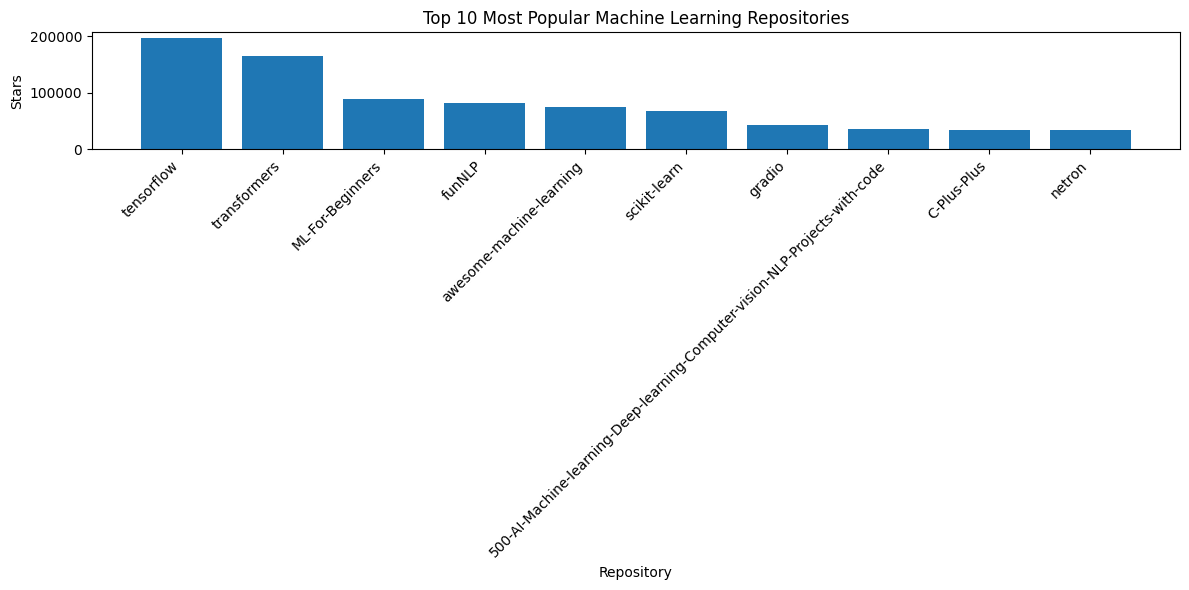

In [130]:
plt.figure(figsize=(12, 6))

plt.bar(top10["name"], top10["stars"])

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Most Popular Machine Learning Repositories")
plt.xlabel("Repository")
plt.ylabel("Stars")

plt.tight_layout()
plt.show()

### Visualization 2: Repository Creation Trends Over Time

This line chart shows how the number of Machine Learning repositories in the dataset varies by creation year.

In [131]:
query = """
SELECT strftime('%Y', created_date) AS year,
       COUNT(*) AS repository_count
FROM Repositories
GROUP BY year
ORDER BY year
"""

creation_trends = pd.read_sql(query, conn)

creation_trends

,year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


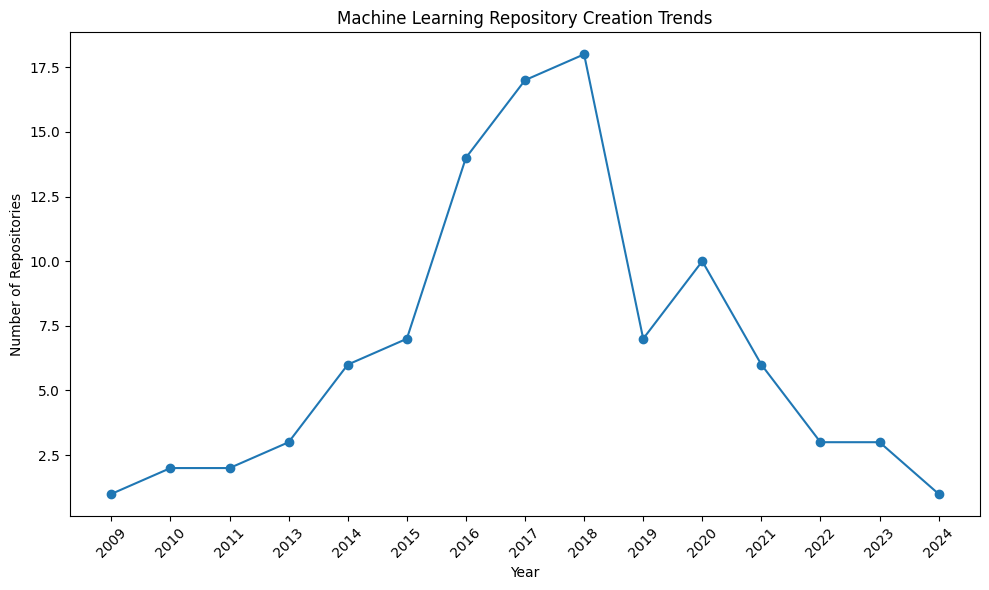

In [132]:
plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["year"],
    creation_trends["repository_count"],
    marker="o"
)

plt.title("Machine Learning Repository Creation Trends")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [133]:
total = pd.read_sql_query("""
SELECT COUNT(*) AS total
FROM Repositories;
""", conn)

print(total)

   total
0    100


In [134]:
avg = pd.read_sql_query("""
SELECT AVG(stars) AS average_stars
FROM Repositories;
""", conn)

print(avg)

   average_stars
0        20805.2


In [135]:
top_repo = pd.read_sql_query("""
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 1;
""", conn)

print(top_repo)

         name   stars
0  tensorflow  197047


In [136]:
top_language = pd.read_sql_query("""
SELECT language, COUNT(*) AS count
FROM Repositories
GROUP BY language
ORDER BY count DESC
LIMIT 1;
""", conn)

print(top_language)

  language  count
0   Python     30


## Insights

### 1. Repository Popularity
The Top 10 analysis shows the repositories with the highest number of stars. These repositories can be considered the most popular projects within the collected Machine Learning dataset.

### 2. Average Popularity
The average number of stars provides a general measure of repository popularity across the dataset.

### 3. Programming Languages
The grouping analysis shows which programming languages are most frequently used in the collected Machine Learning repositories. Languages with more than five repositories were included in the analysis.

### 4. Repository Creation Trend
The creation trend visualization shows how the number of Machine Learning repositories changed over time. This helps identify periods with higher or lower repository creation activity.

### 5. Business Insight
The analysis can help a software company understand popular Machine Learning projects, commonly used programming languages, and changes in repository activity over time. These insights can support data-driven decisions about Machine Learning technologies and trends.


## Ethics Reflection

### 1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because the data may contain missing values, duplicate records, outdated information, or unexpected values. Verifying the data helps ensure that the dataset is accurate and reliable before performing analysis.

### 2. Why should data analysts document the source of their data?

Data analysts should document the source of their data to make the analysis transparent and reproducible. Documenting the source helps others understand where the data came from and how it was collected.

### 3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can affect calculations, statistics, trends, and comparisons. This may lead to incorrect conclusions and unreliable decisions. Therefore, data should be cleaned and checked before using it for analysis.